In [1673]:
import pandas as pd
import matplotlib.pyplot as plt

In [1674]:
energy=pd.read_csv("5G_energy_consumption_dataset.csv")
energy.head(10)

,Time,BS,Energy,load,ESMODE,TXpower
0,20230101 010000,B_0,64.275037,0.487936,0.0,7.101719
1,20230101 020000,B_0,55.904335,0.344468,0.0,7.101719
2,20230101 030000,B_0,57.698057,0.193766,0.0,7.101719
3,20230101 040000,B_0,55.156951,0.222383,0.0,7.101719
4,20230101 050000,B_0,56.053812,0.175436,0.0,7.101719
5,20230101 070000,B_0,82.959641,0.351585,0.0,7.101719
6,20230101 080000,B_0,91.031390,0.759298,0.0,7.101719
7,20230101 090000,B_0,78.176383,0.887798,0.0,7.101719
8,20230101 100000,B_0,72.645740,0.624745,0.0,7.101719
9,20230101 140000,B_0,66.666667,0.437926,0.0,7.101719


In [1675]:
energy.columns

Index(['Time', 'BS', 'Energy', 'load', 'ESMODE', 'TXpower'], dtype='object')

In [1676]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92629 entries, 0 to 92628
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Time     92629 non-null  object 
 1   BS       92629 non-null  object 
 2   Energy   92629 non-null  float64
 3   load     92629 non-null  float64
 4   ESMODE   92629 non-null  float64
 5   TXpower  92629 non-null  float64
dtypes: float64(4), object(2)
memory usage: 4.2+ MB


In [1677]:
#valeur manquante

energy.isna().sum()

Time       0
BS         0
Energy     0
load       0
ESMODE     0
TXpower    0
dtype: int64

In [1678]:
# suppression doublons
energy[energy.duplicated(keep=False)]


,Time,BS,Energy,load,ESMODE,TXpower


In [1679]:
energy[energy.duplicated(keep=False)]

,Time,BS,Energy,load,ESMODE,TXpower


In [1680]:
for i in list(energy.select_dtypes("object").columns) :
    print(energy[i].value_counts)

<bound method IndexOpsMixin.value_counts of 0        20230101 010000
1        20230101 020000
2        20230101 030000
3        20230101 040000
4        20230101 050000
              ...       
92624    20230102 170000
92625    20230102 180000
92626    20230102 210000
92627    20230102 220000
92628    20230102 230000
Name: Time, Length: 92629, dtype: object>
<bound method IndexOpsMixin.value_counts of 0           B_0
1           B_0
2           B_0
3           B_0
4           B_0
          ...  
92624    B_1018
92625    B_1018
92626    B_1018
92627    B_1018
92628    B_1018
Name: BS, Length: 92629, dtype: object>


In [1681]:
energy.dtypes.value_counts()

float64    4
object     2
Name: count, dtype: int64

In [1682]:
energy['Time'] = pd.to_datetime(energy['Time'], format='%Y%m%d %H%M%S')
energy['BS']=energy['BS'].astype("category").cat.codes
energy.corr()

,Time,BS,Energy,load,ESMODE,TXpower
Time,1.000000,-0.026612,0.030404,0.066937,-0.032436,-0.038777
BS,-0.026612,1.000000,-0.026413,-0.035138,-0.002442,0.099563
Energy,0.030404,-0.026413,1.000000,0.643022,-0.271783,0.450760
load,0.066937,-0.035138,0.643022,1.000000,-0.208473,0.200221
ESMODE,-0.032436,-0.002442,-0.271783,-0.208473,1.000000,0.060017
TXpower,-0.038777,0.099563,0.450760,0.200221,0.060017,1.000000


In [1683]:
colonne=[]
for column in list(energy.select_dtypes(include=['int', 'float']).columns):
    Q1 = energy[column].quantile(0.25)
    Q3 = energy[column].quantile(0.75)
    IQR = Q3 - Q1

    # Définir le seuil et détecter les valeurs aberrantes
    threshold = 1.5
    outliers = energy[(energy[column] <  (Q1 - threshold * IQR)) | (energy[column] >  (Q3 + threshold * IQR))]
    if outliers.shape[0] !=0:
        colonne.append(column)
print(colonne)

['Energy', 'load', 'ESMODE', 'TXpower']


In [1684]:
X=energy[energy["load"]>200]
for column in colonne : 
    Q1 = energy[column].quantile(0.25)
    Q3 = energy[column].quantile(0.75)
    IQR = Q3 - Q1

    # Définir le seuil et détecter les valeurs aberrantes
    threshold = 1.5
    outliers = energy[(energy[column] <  (Q1 - threshold * IQR)) | (energy[column] >  (Q3 + threshold * IQR))]
    X = pd.concat([X, outliers], axis=0) 
X.shape

(11489, 6)

In [1685]:
print(X.shape[0]/energy.shape[0])

0.1240324304483477


In [1686]:
energy_filtre=energy[~energy.index.isin(X.index)]

In [1687]:
energy_filtre.corr()

,Time,BS,Energy,load,ESMODE,TXpower
Time,1.000000,-0.020896,0.021186,0.055533,NaN,-0.018132
BS,-0.020896,1.000000,-0.025588,-0.037160,NaN,0.065859
Energy,0.021186,-0.025588,1.000000,0.566873,NaN,0.501358
load,0.055533,-0.037160,0.566873,1.000000,NaN,0.198890
ESMODE,NaN,NaN,NaN,NaN,NaN,NaN
TXpower,-0.018132,0.065859,0.501358,0.198890,NaN,1.000000


In [1688]:
"""from sklearn.preprocessing import OneHotEncoder 
encoder = OneHotEncoder()
energy_encode=encoder.fit_transform(energy[['BS']])"""


"from sklearn.preprocessing import OneHotEncoder \nencoder = OneHotEncoder()\nenergy_encode=encoder.fit_transform(energy[['BS']])"

In [1689]:

energy.head()

,Time,BS,Energy,load,ESMODE,TXpower
0,2023-01-01 01:00:00,0,64.275037,0.487936,0.0,7.101719
1,2023-01-01 02:00:00,0,55.904335,0.344468,0.0,7.101719
2,2023-01-01 03:00:00,0,57.698057,0.193766,0.0,7.101719
3,2023-01-01 04:00:00,0,55.156951,0.222383,0.0,7.101719
4,2023-01-01 05:00:00,0,56.053812,0.175436,0.0,7.101719


In [1690]:
energy.corr()

,Time,BS,Energy,load,ESMODE,TXpower
Time,1.000000,-0.026612,0.030404,0.066937,-0.032436,-0.038777
BS,-0.026612,1.000000,-0.026413,-0.035138,-0.002442,0.099563
Energy,0.030404,-0.026413,1.000000,0.643022,-0.271783,0.450760
load,0.066937,-0.035138,0.643022,1.000000,-0.208473,0.200221
ESMODE,-0.032436,-0.002442,-0.271783,-0.208473,1.000000,0.060017
TXpower,-0.038777,0.099563,0.450760,0.200221,0.060017,1.000000


In [1691]:
energy.describe()

,Time,BS,Energy,load,ESMODE,TXpower
count,92629,92629.000000,92629.000000,92629.000000,92629.000000,92629.000000
mean,2023-01-04 00:31:21.324423424,423.585907,28.138997,0.244705,0.081361,6.765427
min,2023-01-01 01:00:00,0.000000,0.747384,0.000000,0.000000,5.381166
25%,2023-01-02 11:00:00,213.000000,18.236173,0.057370,0.000000,6.427504
50%,2023-01-03 20:00:00,423.000000,24.065770,0.165550,0.000000,6.875934
75%,2023-01-05 14:00:00,629.000000,35.724963,0.363766,0.000000,6.875934
max,2023-01-08 00:00:00,922.000000,100.000000,0.993957,4.000000,8.375336
std,NaN,244.022127,13.934645,0.234677,0.382317,0.309929


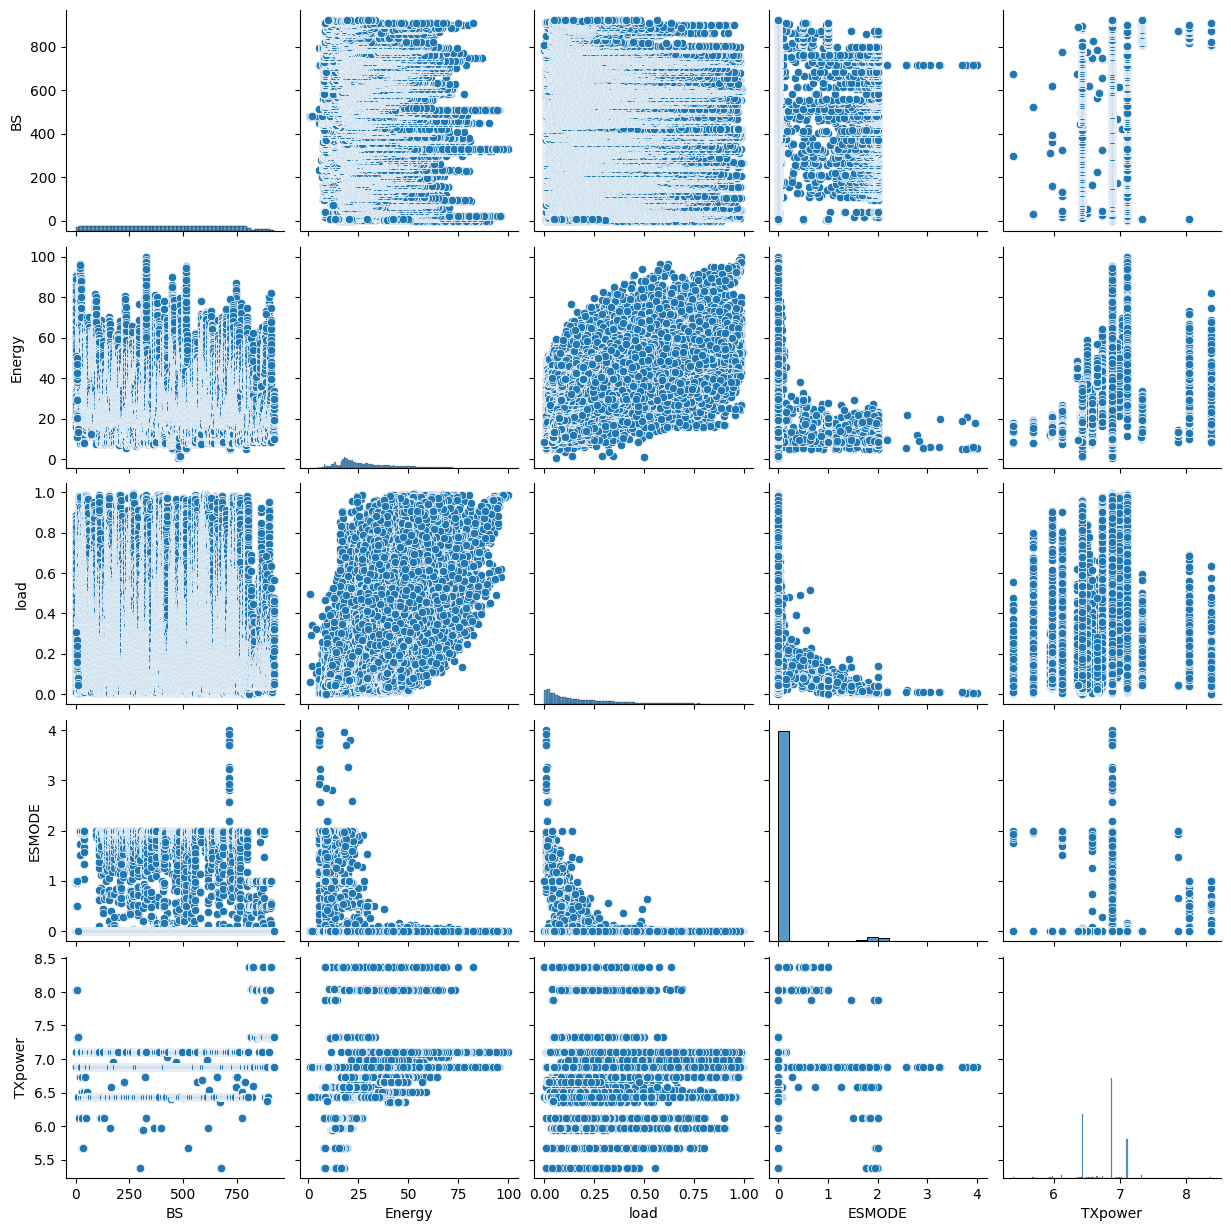

In [1692]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.pairplot(energy)

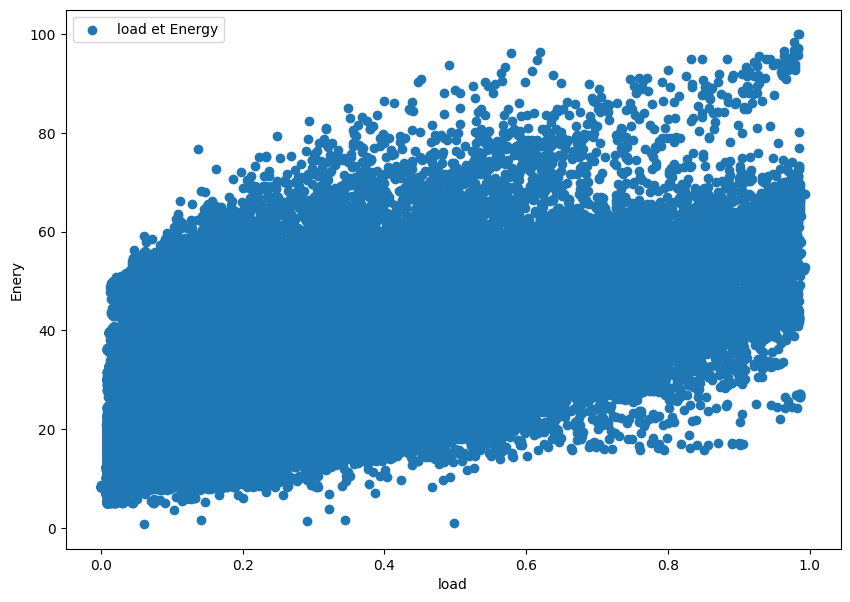

In [1693]:

plt.figure(figsize=(10, 7))
plt.scatter(energy["load"], energy["Energy"], label="load et Energy")

plt.xlabel("load")
plt.ylabel("Enery")
plt.title("")
plt.legend()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9920\3958151692.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(energy["Energy"])


<Axes: xlabel='Energy', ylabel='Density'>

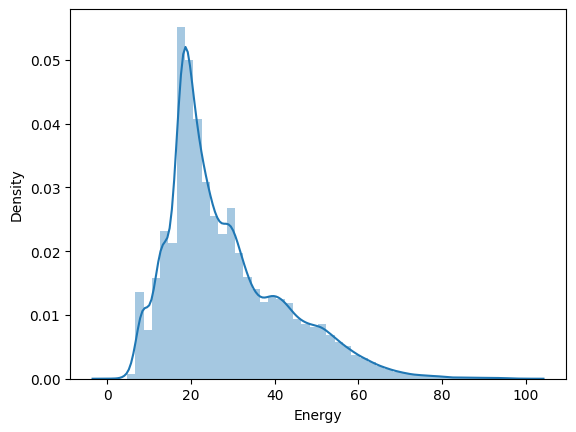

In [1694]:
sns.distplot(energy["Energy"])
 


In [1695]:
# VARIABLE CIBLE = "Energy"
#  FONCTIONNALITE = BS, load, ESMODE, TXpower, +ou- Time
# Divisez votre ensemble de données en ensembles d’entraînement et de test
from sklearn.model_selection import train_test_split
Y=energy["Energy"]
X=energy.drop(["Energy", "Time", "BS"], axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [1696]:

"""X["TXpower"]=(X["TXpower"]-X["TXpower"].min())/(X["TXpower"].max()-X["TXpower"].min())
X.head()"""


'X["TXpower"]=(X["TXpower"]-X["TXpower"].min())/(X["TXpower"].max()-X["TXpower"].min())\nX.head()'

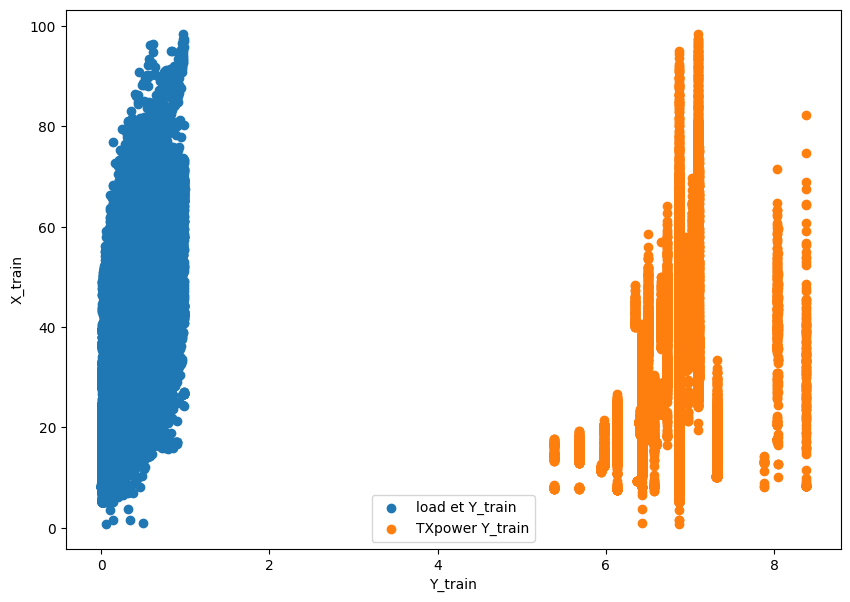

In [1697]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train["load"], Y_train, label="load et Y_train")
plt.scatter(X_train["TXpower"], Y_train, label="TXpower Y_train")

plt.xlabel("Y_train")
plt.ylabel("X_train")
plt.title("")
plt.legend()
plt.show()

In [1698]:
from sklearn.linear_model import LinearRegression
model_multi=LinearRegression()
model_multi.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1699]:
y_predit=model_multi.predict(X_test)

In [1700]:
from sklearn.metrics import mean_absolute_error
mae_erreur=mean_absolute_error(Y_test, y_predit)
print(mae_erreur)

6.896440060542691


In [1701]:
from sklearn.metrics import r2_score
r2_scor=r2_score(Y_test, y_predit)
print(r2_scor)

0.5473968678791109


In [1702]:
from sklearn.linear_model import Ridge

model_ridge=Ridge(alpha=0.7)
model_ridge.fit(X_train, Y_train)
Y_pred=model_ridge.predict(X_test)
print(r2_score(Y_test, Y_pred))



0.5473992602298856


In [1703]:
from sklearn.model_selection import cross_val_score
cross_val_score(LinearRegression(), X_train, Y_train, cv=5).mean()

np.float64(0.553912094187924)

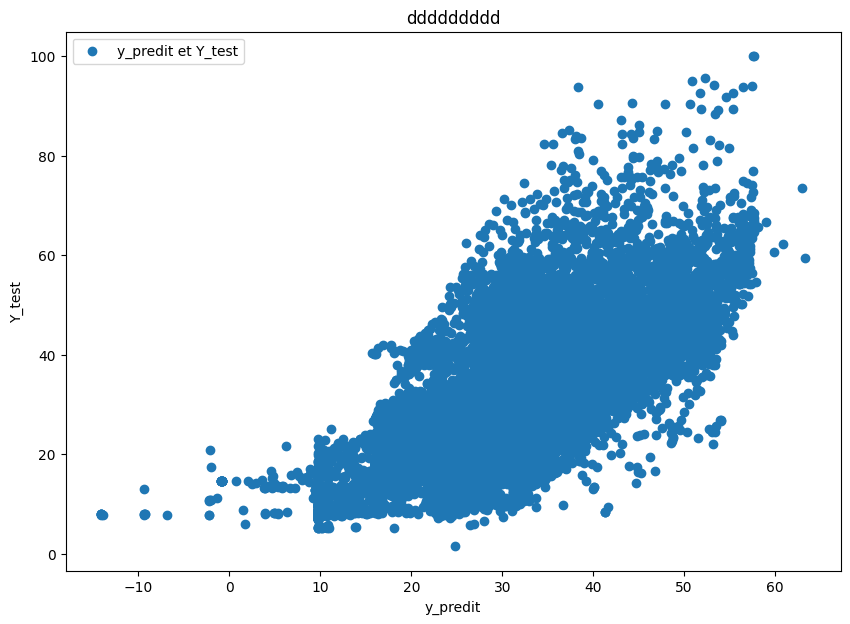

In [1704]:
plt.figure(figsize=(10, 7))
plt.scatter(y_predit, Y_test, label="y_predit et Y_test")

plt.xlabel("y_predit")
plt.ylabel("Y_test")
plt.title("ddddddddd")
plt.legend()
plt.show()